In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data/clean_data.csv")

for col in ["DATE_FROM", "DATE_TO"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")

In [3]:
from tfidf_eval import build_candidate_pool, build_queries, build_rel_map

cutoff_date = pd.Timestamp("2018-01-01")
df["FROM_ID"] = df["CELEX_FROM"].astype(str) + "::" + df["NUMBER_FROM"].astype(str)
df["TO_ID"] = df["CELEX_TO"].astype(str) + "::" + df["NUMBER_TO"].astype(str)

candidates = build_candidate_pool(df, cutoff_date=cutoff_date)
queries = build_queries(df, cutoff_date=cutoff_date)
rel_map = build_rel_map(df, cutoff_date=cutoff_date)

/Users/christianjensen/Documents/Master-Thesis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from retrievers import BM25Retriever, preprocess_utils
from nltk.corpus import stopwords

retriever = BM25Retriever(
        documents=candidates,
        preprocess=preprocess_utils.compose(
            preprocess_utils.lowercase(),
            preprocess_utils.remove_punctuation(),
            preprocess_utils.stopword_filter(
                stopwords=set(
                    stopwords.words("english")
                    + [
                        "<DATE>",
                        "<QUOTED_TEXT>",
                        "<ECLI>",
                        "<ECR>",
                        "<PARAGRAPH>",
                        "<CASE>",
                    ]
                ),
            ),
        ),
    )

ranked_docs = retriever.get_relevant_documents_batch(queries["TEXT"].tolist(), k=50)

Ranking: 100%|██████████| 11890/11890 [00:37<00:00, 313.64it/s]


In [5]:
import networkx as nx

g_undirected = nx.Graph()
g_directed = nx.DiGraph()

for _, row in df[df["DATE_TO"] < cutoff_date].iterrows():
    v = str(row["TO_ID"])
    g_undirected.add_node(v)
    g_directed.add_node(v)

for _, row in df[df["DATE_FROM"] < cutoff_date].iterrows():
    u = str(row["FROM_ID"])
    v = str(row["TO_ID"])
    g_undirected.add_edge(u, v)
    g_directed.add_edge(u, v)

In [6]:
from collections import defaultdict
import networkx as nx
from langchain_core.documents import Document

def compute_distance_to_relevant_docs(
    queries: pd.DataFrame,
    ranked_docs: list[list[Document]],
    rel_map: dict[str, set[str]],
    graph: nx.Graph
) -> dict[str, list]:
    results = defaultdict(list)
    
    for idx, (query_row, retrieved) in enumerate(zip(queries.itertuples(), ranked_docs)):
        query_id = query_row.QID
        relevant_docs = rel_map.get(query_id, set())
        
        if not relevant_docs:
            # No relevant documents for this query
            continue
            
        for rank, doc in enumerate(retrieved):
            # Check if the retrieved doc is already relevant
            doc_id = doc.metadata["id"]
            if doc_id in relevant_docs:
                results['query_id'].append(query_id)
                results['retrieved_doc'].append(doc_id)
                results['rank'].append(rank + 1)
                results['distance'].append(0)
                results['nearest_relevant_doc'].append(doc_id)
                continue
            
            # Compute shortest path to any relevant doc
            min_distance = float('inf')
            nearest_doc = None
            
            # Check if retrieved doc is in the graph
            if doc_id not in graph:
                results['query_id'].append(query_id)
                results['retrieved_doc'].append(doc_id)
                results['rank'].append(rank + 1)
                results['distance'].append(float('inf'))
                results['nearest_relevant_doc'].append(None)
                continue
            
            for rel_doc in relevant_docs:
                if rel_doc not in graph:
                    continue
                    
                try:
                    # Try to find shortest path (undirected)
                    distance = nx.shortest_path_length(graph, source=doc_id, target=rel_doc)
                    if distance < min_distance:
                        min_distance = distance
                        nearest_doc = rel_doc
                except nx.NetworkXNoPath:
                    # No path exists between these nodes
                    continue
            
            results['query_id'].append(query_id)
            results['retrieved_doc'].append(doc_id)
            results['rank'].append(rank + 1)
            results['distance'].append(min_distance if min_distance != float('inf') else float('inf'))
            results['nearest_relevant_doc'].append(nearest_doc)
    
    return dict(results)

# Compute distances for undirected graph
distance_results = compute_distance_to_relevant_docs(
    queries=queries,
    ranked_docs=ranked_docs,
    rel_map=rel_map,
    graph=g_undirected
)

distance_df = pd.DataFrame(distance_results)

,total_retrieved_docs,docs_with_finite_distance,direct_hits,docs_with_infinite_distance,mean_distance,median_distance,min_distance,max_distance,p25_distance,p75_distance,p90_distance
0,454150,168409,10574,275167,10.433896,7.0,1.0,56.0,3.0,16.0,24.0


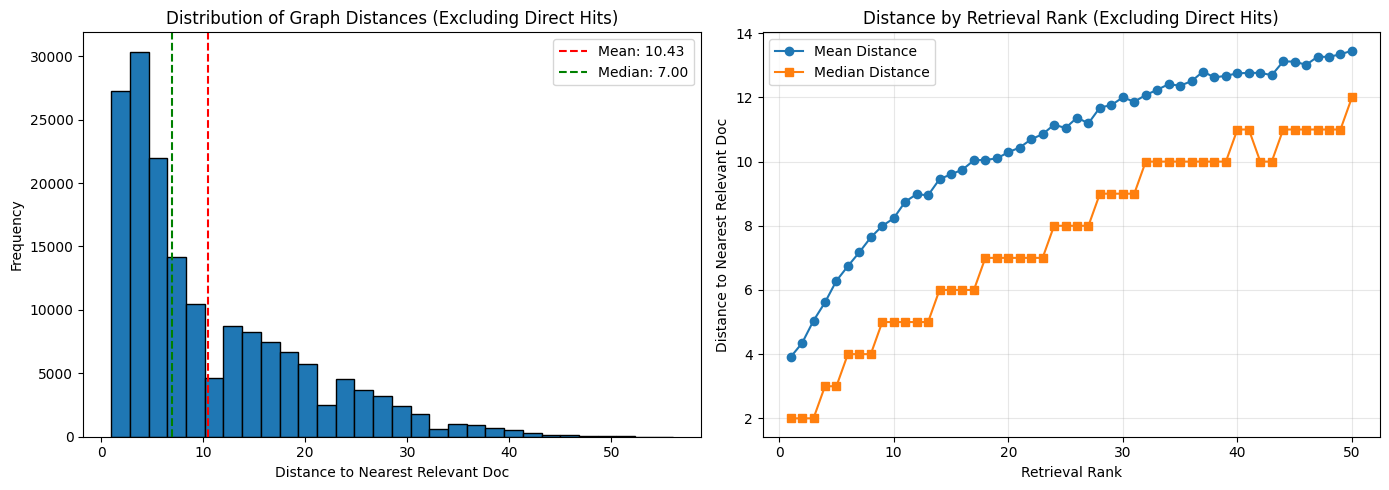

In [7]:
# Compute summary statistics for distances (excluding direct hits)
finite_distances = distance_df[(distance_df['distance'] != float('inf')) & (distance_df['distance'] > 0)]['distance']
infinite_count = (distance_df['distance'] == float('inf')).sum()
direct_hits_count = (distance_df['distance'] == 0).sum()

summary_stats = {
    'total_retrieved_docs': len(distance_df),
    'docs_with_finite_distance': len(finite_distances),
    'direct_hits': direct_hits_count,
    'docs_with_infinite_distance': infinite_count,
    'mean_distance': finite_distances.mean() if len(finite_distances) > 0 else np.nan,
    'median_distance': finite_distances.median() if len(finite_distances) > 0 else np.nan,
    'min_distance': finite_distances.min() if len(finite_distances) > 0 else np.nan,
    'max_distance': finite_distances.max() if len(finite_distances) > 0 else np.nan,
    'p25_distance': finite_distances.quantile(0.25) if len(finite_distances) > 0 else np.nan,
    'p75_distance': finite_distances.quantile(0.75) if len(finite_distances) > 0 else np.nan,
    'p90_distance': finite_distances.quantile(0.90) if len(finite_distances) > 0 else np.nan,
}

summary_df = pd.DataFrame([summary_stats])
display(summary_df)

# Plot distribution of distances (excluding direct hits and infinite distances)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of distances (excluding infinite and direct hits)
axes[0].hist(finite_distances, bins=30, edgecolor='black')
axes[0].set_xlabel('Distance to Nearest Relevant Doc')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Graph Distances (Excluding Direct Hits)')
axes[0].axvline(finite_distances.mean(), color='red', linestyle='--', label=f'Mean: {finite_distances.mean():.2f}')
axes[0].axvline(finite_distances.median(), color='green', linestyle='--', label=f'Median: {finite_distances.median():.2f}')
axes[0].legend()

# Distance by rank (excluding direct hits)
rank_distance = distance_df[(distance_df['distance'] != float('inf')) & (distance_df['distance'] > 0)].groupby('rank')['distance'].agg(['mean', 'median', 'count'])
axes[1].plot(rank_distance.index, rank_distance['mean'], marker='o', label='Mean Distance')
axes[1].plot(rank_distance.index, rank_distance['median'], marker='s', label='Median Distance')
axes[1].set_xlabel('Retrieval Rank')
axes[1].set_ylabel('Distance to Nearest Relevant Doc')
axes[1].set_title('Distance by Retrieval Rank (Excluding Direct Hits)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
def classify_relationship_to_relevant(
    doc_id: str,
    relevant_docs: set[str],
    graph: nx.DiGraph,
    graph_reversed: nx.DiGraph,
    max_depth: int = 6,
) -> str:
    """Classify the relationship of a retrieved document to any relevant document.

    The first matching label in the following priority order is returned:
    exact > parent > child > sibling > ancestor > descendant > unrelated > not_in_graph
    """
    if doc_id not in graph:
        return "not_in_graph"

    # Filter relevant docs to those present in the graph
    rel_in_graph: set[str] = {r for r in relevant_docs if r in graph}
    if not rel_in_graph:
        return "unrelated"

    # exact
    if doc_id in rel_in_graph:
        return "exact"

    # parent / child (direct)
    for r in rel_in_graph:
        if graph.has_edge(doc_id, r):
            return "parent"
        if graph.has_edge(r, doc_id):
            return "child"

    # sibling (shared parent)
    parents = set(graph.predecessors(doc_id))
    if parents:
        for p in parents:
            children_p = set(graph.successors(p))
            if rel_in_graph & children_p:
                return "sibling"

    # ancestor: forward reach from doc_id to any relevant (length >= 2)
    forward_lengths = nx.single_source_shortest_path_length(graph, doc_id, cutoff=max_depth)
    for r in rel_in_graph:
        d = forward_lengths.get(r)
        if d is not None and d >= 2:
            return "ancestor"

    # descendant: forward reach from relevant to doc (length >= 2) -> backward from doc
    backward_lengths = nx.single_source_shortest_path_length(graph_reversed, doc_id, cutoff=max_depth)
    for r in rel_in_graph:
        d = backward_lengths.get(r)
        if d is not None and d >= 2:
            return "descendant"

    return "unrelated"


# Build relationship labels for all retrieved docs using existing distance_df and rel_map
Gd: nx.DiGraph = g_directed
Gd_rev: nx.DiGraph = Gd.reverse(copy=False)

records: list[dict] = []
for qid, group in distance_df.groupby("query_id"):
    rel_set: set[str] = set(rel_map.get(qid, set()))
    if not rel_set:
        continue
    for row in group.itertuples():
        doc_id: str = row.retrieved_doc
        # Gate expensive reachability: if undirected distance is infinite, skip ancestor/descendant
        dval = getattr(row, "distance", None)
        max_d = 15 if (dval is None or dval != float("inf")) else 0
        label: str = classify_relationship_to_relevant(
            doc_id=doc_id,
            relevant_docs=rel_set,
            graph=Gd,
            graph_reversed=Gd_rev,
            max_depth=max_d,
        )
        records.append({
            "query_id": qid,
            "retrieved_doc": doc_id,
            "rank": int(row.rank),
            "relationship": label,
        })

relationship_df: pd.DataFrame = pd.DataFrame.from_records(records)

# Overall counts and percentages
counts = relationship_df["relationship"].value_counts(dropna=False)
summary = (
    counts.rename_axis("relationship").reset_index(name="count")
)
summary["percentage"] = 100.0 * summary["count"] / float(len(relationship_df))

# Also show distribution among finite-distance near-misses if available
if "distance" in distance_df.columns:
    merged = relationship_df.merge(
        distance_df[["query_id", "retrieved_doc", "distance"]],
        on=["query_id", "retrieved_doc"],
        how="left",
    )
    near = merged[(merged["distance"] != float("inf")) & (merged["distance"] > 0)]
    counts_near = near["relationship"].value_counts(dropna=False)
    summary_near = counts_near.rename_axis("relationship").reset_index(name="count")
    summary_near["percentage"] = 100.0 * summary_near["count"] / float(len(near))
else:
    summary_near = pd.DataFrame(columns=["relationship", "count", "percentage"])

# Display
display(summary.sort_values("count", ascending=False).reset_index(drop=True).round({"percentage": 2}))
display(summary_near.sort_values("count", ascending=False).reset_index(drop=True).round({"percentage": 2}))


,relationship,count,percentage
0,unrelated,416616,91.74
1,exact,10574,2.33
2,descendant,8376,1.84
3,child,6894,1.52
4,parent,5073,1.12
5,ancestor,3676,0.81
6,sibling,2941,0.65


,relationship,count,percentage
0,unrelated,141449,83.99
1,descendant,8376,4.97
2,child,6894,4.09
3,parent,5073,3.01
4,ancestor,3676,2.18
5,sibling,2941,1.75


In [9]:
# Analysis excluding direct hits and infinite distances
# Filter to only include "near misses" - documents that are close but not exactly relevant
filtered_df = distance_df[(distance_df['distance'] != float('inf')) & (distance_df['distance'] > 0)].copy()

print(f"Total retrieved docs: {len(distance_df)}")
print(f"Direct hits (distance=0): {(distance_df['distance'] == 0).sum()} ({100*(distance_df['distance'] == 0).sum()/len(distance_df):.2f}%)")
print(f"Infinite distance: {(distance_df['distance'] == float('inf')).sum()} ({100*(distance_df['distance'] == float('inf')).sum()/len(distance_df):.2f}%)")
print(f"Near misses (analyzed): {len(filtered_df)} ({100*len(filtered_df)/len(distance_df):.2f}%)")
print(f"\n--- Distance Statistics for Near Misses ---")
print(f"Mean distance: {filtered_df['distance'].mean():.2f}")
print(f"Median distance: {filtered_df['distance'].median():.2f}")
print(f"Min distance: {filtered_df['distance'].min()}")
print(f"Max distance: {filtered_df['distance'].max()}")
print(f"25th percentile: {filtered_df['distance'].quantile(0.25):.2f}")
print(f"75th percentile: {filtered_df['distance'].quantile(0.75):.2f}")
print(f"90th percentile: {filtered_df['distance'].quantile(0.90):.2f}")

Total retrieved docs: 454150
Direct hits (distance=0): 10574 (2.33%)
Infinite distance: 275167 (60.59%)
Near misses (analyzed): 168409 (37.08%)

--- Distance Statistics for Near Misses ---
Mean distance: 10.43
Median distance: 7.00
Min distance: 1.0
Max distance: 56.0
25th percentile: 3.00
75th percentile: 16.00
90th percentile: 24.00


In [10]:
from typing import Iterable

def expand_from_seeds(seeds: set[str], graph: nx.Graph, hops: int) -> set[str]:
    visited: set[str] = set(seeds)
    frontier: set[str] = set(seeds)
    for _ in range(int(hops)):
        if not frontier:
            break
        neighbors: set[str] = set()
        for u in frontier:
            if u in graph:
                neighbors.update(graph.neighbors(u))
        frontier = neighbors - visited
        visited |= frontier
    return visited


def compute_expanded_retrieval_metrics(
    *,
    distance_df: pd.DataFrame,
    rel_map: dict[str, set[str]],
    graph: nx.Graph,
    k_values: Iterable[int] = (1, 3, 5, 10, 20, 50),
    hop_values: Iterable[int] = (0, 1, 2, 3, 5, 10),
) -> pd.DataFrame:
    # Prepare top-k seeds per query using rank
    required_cols = {"query_id", "retrieved_doc", "rank"}
    missing = required_cols - set(distance_df.columns)
    if missing:
        raise ValueError(f"distance_df missing required columns: {sorted(missing)}")

    eval_df = distance_df[["query_id", "retrieved_doc", "rank"]].copy()
    valid_qids = [qid for qid in eval_df["query_id"].unique() if len(rel_map.get(qid, set())) > 0]
    eval_df = eval_df[eval_df["query_id"].isin(valid_qids)].copy()
    eval_df = eval_df.sort_values(["query_id", "rank"])  # ascending rank

    rows: list[dict[str, object]] = []

    for hops in hop_values:
        grouped = eval_df.groupby("query_id", sort=False)
        for k in k_values:
            precisions: list[float] = []
            recalls: list[float] = []
            n_expanded: list[int] = []
            n_q: int = 0
            for qid, qdf in grouped:
                rel_set = rel_map.get(qid, set())
                if not rel_set:
                    continue
                seeds = set(qdf.head(int(k))["retrieved_doc"].astype(str).tolist())
                if not seeds:
                    continue
                expanded = expand_from_seeds(seeds, graph, int(hops))
                if not expanded:
                    continue
                hits = len(expanded & rel_set)
                precision_q = hits / float(len(expanded))
                recall_q = hits / float(len(rel_set)) if len(rel_set) > 0 else 0.0
                precisions.append(precision_q)
                recalls.append(recall_q)
                n_expanded.append(len(expanded))
                n_q += 1
            precision = float(np.mean(precisions)) if precisions else 0.0
            recall = float(np.mean(recalls)) if recalls else 0.0
            f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0
            mean_expanded = float(np.mean(n_expanded)) if n_expanded else 0.0
            rows.append({
                "k": int(k),
                "hops": int(hops),
                "precision_expanded": precision,
                "recall_expanded": recall,
                "f1_expanded": f1,
                "mean_expanded": mean_expanded,
            })
    return pd.DataFrame(rows).sort_values(["hops", "k"]).reset_index(drop=True)


# Compute and display expanded-retrieval metrics
k_grid = [1, 3, 5, 10, 20, 50]
hop_grid = [0, 1, 2, 3, 5, 10]
expanded_metrics_df = compute_expanded_retrieval_metrics(
    distance_df=distance_df,
    rel_map=rel_map,
    graph=g_undirected,
    k_values=k_grid,
    hop_values=hop_grid,
)

print(expanded_metrics_df.round(4))

     k  hops  precision_expanded  recall_expanded  f1_expanded  mean_expanded
0    1     0              0.5195           0.4085       0.4573         1.0000
1    3     0              0.2646           0.5706       0.3615         3.0000
2    5     0              0.1786           0.6227       0.2776         5.0000
3   10     0              0.1001           0.6784       0.1745        10.0000
4   20     0              0.0544           0.7208       0.1011        20.0000
5   50     0              0.0233           0.7562       0.0452        50.0000
6    1     1              0.3745           0.5563       0.4476         3.0846
7    3     1              0.1450           0.6728       0.2385         8.6670
8    5     1              0.0880           0.7097       0.1567        14.2454
9   10     1              0.0449           0.7502       0.0847        28.2774
10  20     1              0.0227           0.7781       0.0441        56.6153
11  50     1              0.0091           0.8032       0.0180  